In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report



In [5]:
df = pd.read_csv("online_shoppers_intention.csv")

In [6]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [7]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [8]:
df.info

<bound method DataFrame.info of        Administrative  Administrative_Duration  Informational  \
0                   0                      0.0              0   
1                   0                      0.0              0   
2                   0                      0.0              0   
3                   0                      0.0              0   
4                   0                      0.0              0   
...               ...                      ...            ...   
12325               3                    145.0              0   
12326               0                      0.0              0   
12327               0                      0.0              0   
12328               4                     75.0              0   
12329               0                      0.0              0   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                         0.0               1                 0.000000   
1                         0.0          

In [9]:
df.shape

(12330, 18)

In [11]:
df['Revenue'] = df['Revenue'].astype(int)

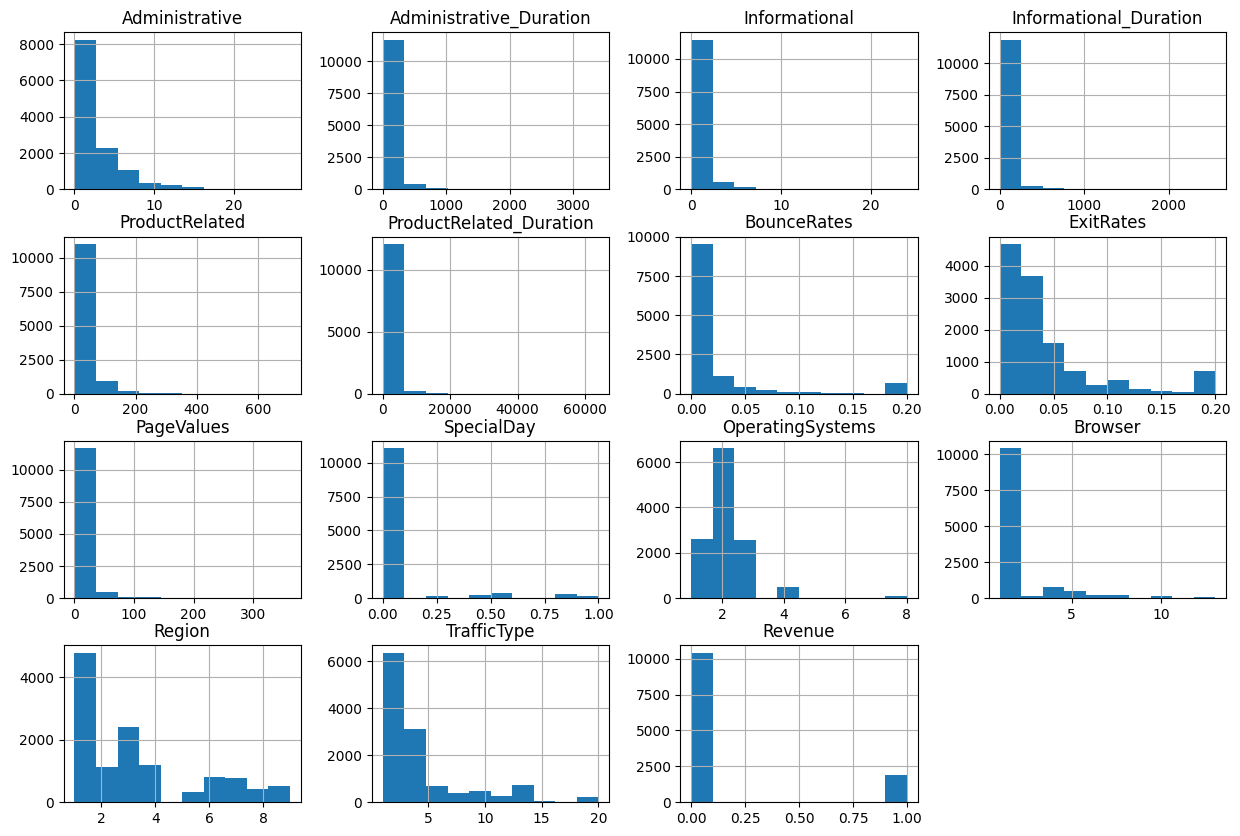

In [12]:
df.hist(figsize=(15,10))
plt.show()

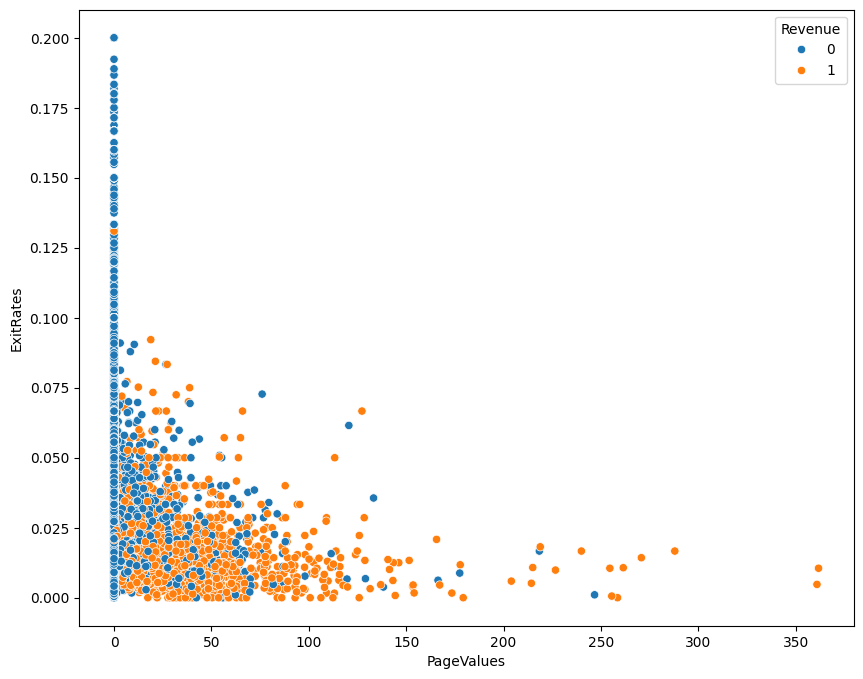

In [14]:
plt.figure(figsize=(10,8))
sns.scatterplot(x='PageValues',y='ExitRates',hue='Revenue',data=df)
plt.show()

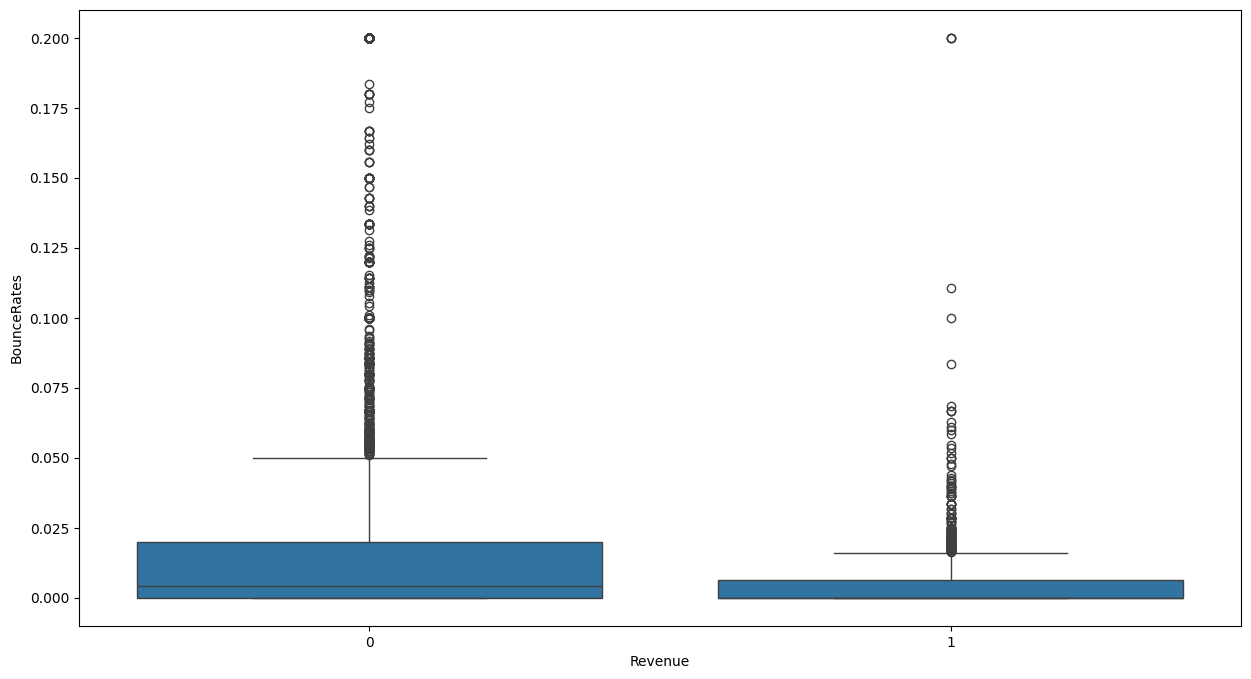

In [18]:
plt.figure(figsize=(15,8))
sns.boxplot(x='Revenue',y='BounceRates',data=df)
plt.show()

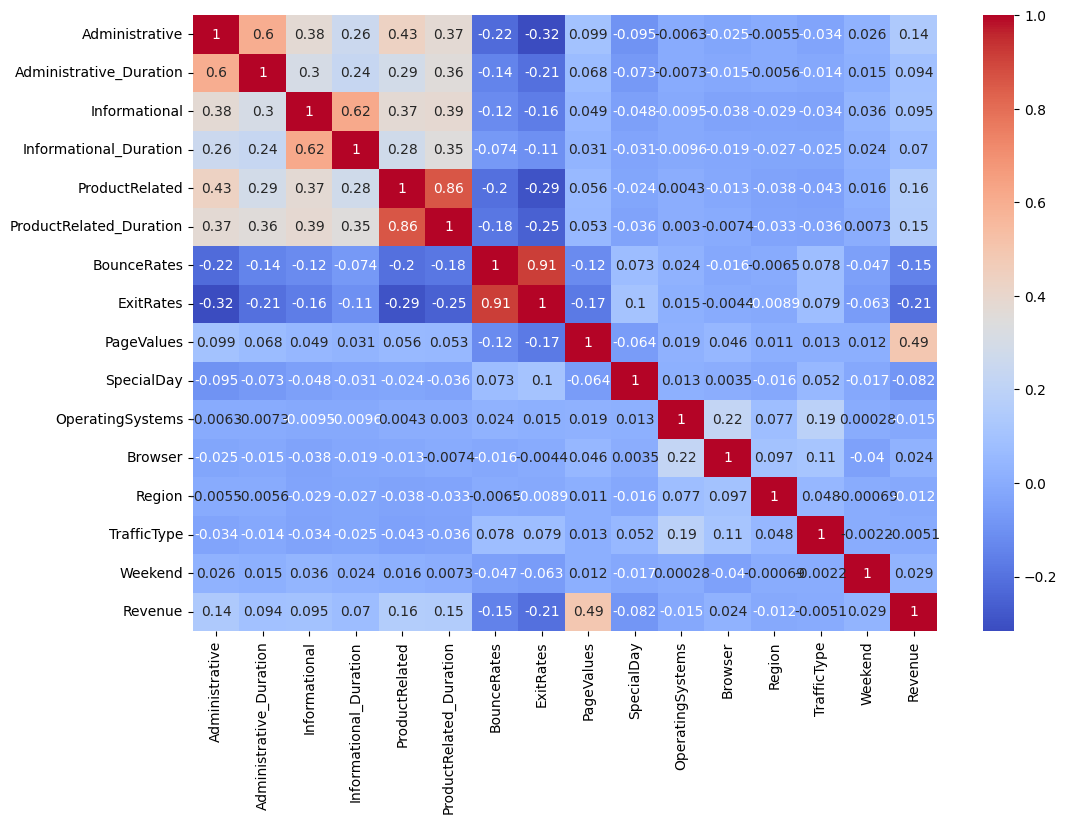

In [19]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()


In [20]:
import plotly.express as px

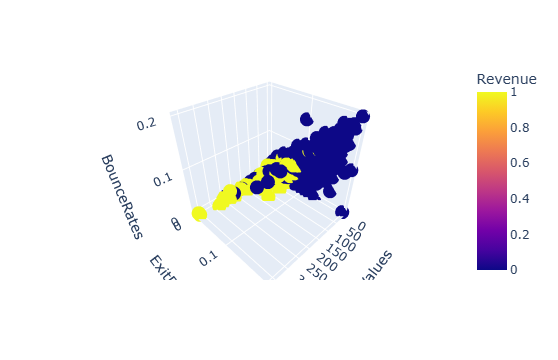

In [21]:
fig = px.scatter_3d(
    df,
    x='PageValues',
    y='ExitRates',
    z='BounceRates',
    color='Revenue'
)
fig.show()

In [22]:
cat_features = df.select_dtypes(include=['object']).columns.tolist()

In [23]:
X = df.drop('Revenue', axis=1)
y = df['Revenue']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    verbose=100
)

In [26]:

model.fit(X_train, y_train, cat_features=cat_features)

0:	learn: 0.6303533	total: 286ms	remaining: 2m 22s
100:	learn: 0.2022220	total: 8.52s	remaining: 33.7s
200:	learn: 0.1834299	total: 16.7s	remaining: 24.9s
300:	learn: 0.1671472	total: 24.8s	remaining: 16.4s
400:	learn: 0.1547895	total: 33.1s	remaining: 8.16s
499:	learn: 0.1427186	total: 42s	remaining: 0us


CatBoostClassifier(depth=6, iterations=500, learning_rate=0.05, loss_function='Logloss', verbose=100)

In [27]:
y_pred = model.predict(X_test)

In [28]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8933495539334956
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2055
           1       0.73      0.57      0.64       411

    accuracy                           0.89      2466
   macro avg       0.82      0.77      0.79      2466
weighted avg       0.89      0.89      0.89      2466



In [29]:
model.get_feature_importance()

array([ 4.41775826,  4.9715154 ,  0.97124699,  2.28906609,  5.33018634,
        6.83285766,  3.95216848,  5.27183035, 24.35027446,  3.12008255,
       25.64296703,  1.07361596,  1.78852071,  2.15404571,  3.57434417,
        3.10849346,  1.15102638])